## Analysis of Invalid Traffic(IVT) for Ad Traffic Quality

About : This assignment analyzes ad traffic data from 6 apps to identify patterns that flagged the app as Invalid or Valid. This study helps in revealing automated traffic. For statistical and visual analysis Python and Power BI was used. ETL method was in Power BI. For correlation analysis, we use EDA (Exploratory Data Analysis).

In [197]:
import pandas as pd
import matplotlib.pyplot as plt

In [198]:
columns = [
    'Date',
    'unique_idfas',
    'unique_ips',
    'unique_uas',
    'total_requests',
    'requests_per_idfa',
    'impressions',
    'impressions_per_idfa',
    'idfa_ip_ratio',
    'idfa_ua_ratio',
    'IVT'
]

# Extracting the data from the excel sheet

In [199]:
import pandas as pd

file = 'Data Analytics Assignment.xlsx'
raw_data = pd.read_excel(file, sheet_name=None, header=None)


The data is split into Daily, Hourly and Total data for each app

In [200]:
daily_data = {}
hourly_data = {}
total_data = {}

for name, df in raw_data.items():
    total_idx = df.index[df[1].astype(str).str.contains('Total Data', case=False, na=False)].tolist()
    daily_idx = df.index[df[1].astype(str).str.contains('Daily Data', case=False, na=False)].tolist()
    hourly_idx = df.index[df[1].astype(str).str.contains('Hourly Data', case=False, na=False)].tolist()
    if total_idx:
        total_df = df.iloc[total_idx[0]+2 : daily_idx[0]].dropna(how='all', axis=1)
        total_data[name] = total_df
    if daily_idx:
        daily_df = df.iloc[daily_idx[0]+2 : hourly_idx[0]].dropna(how='all', axis=1)
        daily_data[name] = daily_df
    if hourly_idx:
        hourly_df = df.iloc[hourly_idx[0]+2 :].dropna(how='all', axis=1)
        hourly_data[name] = hourly_df

In [201]:
daily_data['Valid 1']



,1,2,3,4,5,6,7,8,9,10,11
9,2025-09-11 00:00:00,93345,93340,22,99280,1.063581,0,0,1.000054,4242.954545,0.003456
10,2025-09-12 00:00:00,515646,515307,25,649515,1.259614,0,0,1.000658,20625.84,0.003409
11,2025-09-13 00:00:00,406993,406729,25,473346,1.163032,0,0,1.000649,16279.72,0.006033
12,2025-09-14 00:00:00,400917,400668,26,467152,1.165209,0,0,1.000621,15419.884615,0.003836
13,2025-09-15 00:00:00,76526,76519,21,81409,1.063808,0,0,1.000091,3644.095238,0.002968
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Formatting and Cleaning 

The index is set to normal and columns is assigned to each data table for easier analysis

daily_data_valid is transformed.

In [202]:
daily_data_valid_1 = daily_data['Valid 1'].reset_index(drop=True)
daily_data_valid_2 = daily_data['Valid 2'].reset_index(drop=True)
daily_data_valid_3 = daily_data['Valid 3'].reset_index(drop=True)


In [203]:
daily_data_valid_1.columns = columns
daily_data_valid_2.columns = columns
daily_data_valid_3.columns = columns

----------------------------------------------------

daily_data_invalid is transformed.

In [204]:
daily_data_invalid_1 = daily_data['Invalid 1'].reset_index(drop=True)
daily_data_invalid_2 = daily_data['Invalid 2'].reset_index(drop=True)
daily_data_invalid_3 = daily_data['Invalid 3'].reset_index(drop=True)

In [205]:
daily_data_invalid_1.columns = columns
daily_data_invalid_2.columns = columns
daily_data_invalid_3.columns = columns

--------------------------------------------------------------

hourly_data_valid is transformed.

In [206]:
hourly_data_valid_1 = hourly_data['Valid 1'].reset_index(drop=True)
hourly_data_valid_2 = hourly_data['Valid 2'].reset_index(drop=True)
hourly_data_valid_3 = hourly_data['Valid 2'].reset_index(drop=True)

In [207]:
hourly_data_valid_1.columns = columns
hourly_data_valid_2.columns = columns
hourly_data_valid_3.columns = columns

-------------------------------------------------------

hourly_data_invalid is transformed.

In [208]:
hourly_data_invalid_1 = hourly_data['Invalid 1'].reset_index(drop=True)
hourly_data_invalid_2 = hourly_data['Invalid 2'].reset_index(drop=True)
hourly_data_invalid_3 = hourly_data['Invalid 3'].reset_index(drop=True)

In [209]:
hourly_data_invalid_1.columns = columns
hourly_data_invalid_2.columns = columns
hourly_data_invalid_3.columns = columns


-------------------------------------------------------

All the datasets are grouped in daily_combined and hourly_combined

In [210]:
import pandas as pd

daily_combined = pd.concat([
    daily_data_valid_1.assign(app='valid_1', level='daily'),
    daily_data_valid_2.assign(app='valid_2', level='daily'),
    daily_data_valid_3.assign(app='valid_3', level='daily'),
    daily_data_invalid_1.assign(app='invalid_1', level='daily'),
    daily_data_invalid_2.assign(app='invalid_2', level='daily'),
    daily_data_invalid_3.assign(app='invalid_3', level='daily')
], ignore_index=True)


In [211]:
daily_combined

,Date,unique_idfas,unique_ips,unique_uas,total_requests,requests_per_idfa,impressions,impressions_per_idfa,idfa_ip_ratio,idfa_ua_ratio,IVT,app,level
0,2025-09-11 00:00:00,93345,93340,22,99280,1.063581,0,0,1.000054,4242.954545,0.003456,valid_1,daily
1,2025-09-12 00:00:00,515646,515307,25,649515,1.259614,0,0,1.000658,20625.84,0.003409,valid_1,daily
2,2025-09-13 00:00:00,406993,406729,25,473346,1.163032,0,0,1.000649,16279.72,0.006033,valid_1,daily
3,2025-09-14 00:00:00,400917,400668,26,467152,1.165209,0,0,1.000621,15419.884615,0.003836,valid_1,daily
4,2025-09-15 00:00:00,76526,76519,21,81409,1.063808,0,0,1.000091,3644.095238,0.002968,valid_1,daily
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,valid_1,daily
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,valid_1,daily
7,2025-09-11 00:00:00,51817,51696,160,56301,1.086535,0,0,1.002341,323.85625,0.047394,valid_2,daily
8,2025-09-12 00:00:00,254641,253038,252,311936,1.225003,0,0,1.006335,1010.480159,0.058381,valid_2,daily
9,2025-09-13 00:00:00,236217,234918,264,272815,1.154934,0,0,1.00553,894.761364,0.057921,valid_2,daily


In [212]:
hourly_combined = pd.concat([
    hourly_data_valid_1.assign(app='valid_1', level='hourly'),
    hourly_data_valid_2.assign(app='valid_2', level='hourly'),
    hourly_data_valid_3.assign(app='valid_3', level='hourly'),
    hourly_data_invalid_1.assign(app='invalid_1', level='hourly'),
    hourly_data_invalid_2.assign(app='invalid_2', level='hourly'),
    hourly_data_invalid_3.assign(app='invalid_3', level='hourly')
], ignore_index=True)


In [213]:
hourly_combined

,Date,unique_idfas,unique_ips,unique_uas,total_requests,requests_per_idfa,impressions,impressions_per_idfa,idfa_ip_ratio,idfa_ua_ratio,IVT,app,level
0,2025-09-11 14:00:00,3535,3535,17,3577,1.011881,0,0,1,207.941176,0.010695,valid_1,hourly
1,2025-09-11 15:00:00,7254,7254,17,7361,1.01475,0,0,1,426.705882,0,valid_1,hourly
2,2025-09-11 16:00:00,13737,13737,17,14073,1.024459,0,0,1,808.058824,0,valid_1,hourly
3,2025-09-11 17:00:00,13800,13800,18,14074,1.019855,0,0,1,766.666667,0.00625,valid_1,hourly
4,2025-09-11 18:00:00,8696,8696,19,8796,1.0115,0,0,1,457.684211,0,valid_1,hourly
...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,2025-09-14 21:00:00,7865,7864,96,8438,1.072854,0,0,1.000127,81.927083,1,invalid_3,hourly
500,2025-09-14 22:00:00,7780,7777,96,8225,1.057198,0,0,1.000386,81.041667,1,invalid_3,hourly
501,2025-09-14 23:00:00,15669,15667,173,16890,1.077925,0,0,1.000128,90.572254,1,invalid_3,hourly
502,2025-09-15 00:00:00,11223,11219,163,11862,1.056937,0,0,1.000357,68.852761,1,invalid_3,hourly


Rows with null values are removed.

In [214]:
daily_combined = daily_combined.dropna(ignore_index=True)

In [215]:
hourly_combined = hourly_combined.dropna(ignore_index=True)

The cleaned data is shown as below.

In [216]:
daily_combined

,Date,unique_idfas,unique_ips,unique_uas,total_requests,requests_per_idfa,impressions,impressions_per_idfa,idfa_ip_ratio,idfa_ua_ratio,IVT,app,level
0,2025-09-11 00:00:00,93345,93340,22,99280,1.063581,0,0,1.000054,4242.954545,0.003456,valid_1,daily
1,2025-09-12 00:00:00,515646,515307,25,649515,1.259614,0,0,1.000658,20625.84,0.003409,valid_1,daily
2,2025-09-13 00:00:00,406993,406729,25,473346,1.163032,0,0,1.000649,16279.72,0.006033,valid_1,daily
3,2025-09-14 00:00:00,400917,400668,26,467152,1.165209,0,0,1.000621,15419.884615,0.003836,valid_1,daily
4,2025-09-15 00:00:00,76526,76519,21,81409,1.063808,0,0,1.000091,3644.095238,0.002968,valid_1,daily
5,2025-09-11 00:00:00,51817,51696,160,56301,1.086535,0,0,1.002341,323.85625,0.047394,valid_2,daily
6,2025-09-12 00:00:00,254641,253038,252,311936,1.225003,0,0,1.006335,1010.480159,0.058381,valid_2,daily
7,2025-09-13 00:00:00,236217,234918,264,272815,1.154934,0,0,1.00553,894.761364,0.057921,valid_2,daily
8,2025-09-14 00:00:00,264396,262952,266,310011,1.172525,0,0,1.005491,993.969925,0.053956,valid_2,daily
9,2025-09-15 00:00:00,48280,48234,186,52446,1.086288,0,0,1.000954,259.569892,0.074098,valid_2,daily


impressions column includes all data as 0. Either the ads are not getting rendered or we need to analyze suspicious traffic patterns before actual ads are served.

In [217]:
daily_combined = daily_combined.drop(['impressions', 'impressions_per_idfa'], axis=1)
hourly_combined = hourly_combined.drop(['impressions', 'impressions_per_idfa'], axis=1)


daily_combined and hourly_combined are divided into valid and invalid with a new column named 'app'. This helps in plotting the correlation matrix for valid and invalid apps for comparitive analysis.

In [218]:
daily_valid_apps = daily_combined[daily_combined['app'].str.contains('valid')]
daily_invalid_apps = daily_combined[daily_combined['app'].str.contains('invalid')]
hourly_valid_apps = hourly_combined[hourly_combined['app'].str.contains('valid')]
hourly_invalid_apps = hourly_combined[hourly_combined['app'].str.contains('invalid')]


Calculating Statistical measures of each column in VALID and INVALID Apps.

In [219]:
cols = ['unique_idfas', 'unique_ips', 'unique_uas', 'total_requests',
        'requests_per_idfa', 'idfa_ip_ratio', 'idfa_ua_ratio', 'IVT']

In [220]:
daily_valid_apps[cols] = daily_valid_apps[cols].apply(pd.to_numeric, errors='coerce')

daily_valid_apps[cols].describe()

,unique_idfas,unique_ips,unique_uas,total_requests,requests_per_idfa,idfa_ip_ratio,idfa_ua_ratio,IVT
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,189487.400000,188421.833333,298.066667,227723.866667,1.166771,1.004420,3975.384423,0.372308
std,130477.433665,129836.298791,359.564002,162472.155250,0.087116,0.006793,6078.945365,0.459442
min,21796.000000,21785.000000,21.000000,23467.000000,1.037311,1.000054,33.657623,0.001874
25%,80356.500000,80346.750000,25.000000,85511.000000,1.086350,1.000615,275.641482,0.004816
50%,190498.500000,188533.000000,227.000000,241274.000000,1.160787,1.000838,893.762704,0.055939
75%,255362.500000,251236.500000,265.500000,309426.250000,1.240973,1.005591,4093.239719,0.994807
max,515646.000000,515307.000000,1232.000000,649515.000000,1.358320,1.025221,20625.840000,1.000000


In [221]:
daily_invalid_apps[cols] = daily_invalid_apps[cols].apply(pd.to_numeric, errors='coerce')

daily_invalid_apps[cols].describe()

C:\Users\Kerissa College\AppData\Local\Temp\ipykernel_23804\1476508017.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_invalid_apps[cols] = daily_invalid_apps[cols].apply(pd.to_numeric, errors='coerce')


,unique_idfas,unique_ips,unique_uas,total_requests,requests_per_idfa,idfa_ip_ratio,idfa_ua_ratio,IVT
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,151792.800000,151435.866667,505.666667,183886.533333,1.171673,1.001830,495.481258,0.722268
std,101275.072262,101028.799675,406.176363,129556.804658,0.098148,0.002388,431.137966,0.417238
min,21796.000000,21785.000000,182.000000,23467.000000,1.037311,1.000077,33.657623,0.003532
25%,73460.500000,73446.000000,238.500000,79026.000000,1.085198,1.000352,123.528578,0.526084
50%,150568.000000,150428.000000,262.000000,171836.000000,1.158541,1.000667,395.896552,0.995055
75%,224345.500000,223571.000000,804.000000,270662.500000,1.250540,1.002248,876.504304,0.999256
max,376599.000000,376351.000000,1232.000000,480852.000000,1.358320,1.006472,1405.220149,1.000000


In [222]:
hourly_valid_apps[cols] = hourly_valid_apps[cols].apply(pd.to_numeric, errors='coerce')

hourly_valid_apps[cols].describe()

,unique_idfas,unique_ips,unique_uas,total_requests,requests_per_idfa,idfa_ip_ratio,idfa_ua_ratio,IVT
count,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000
mean,12318.843254,12316.367063,183.944444,12968.289683,1.041755,1.000167,225.882330,0.396492
std,11711.597541,11709.100779,164.434911,12663.964417,0.032950,0.000201,506.790274,0.467006
min,1665.000000,1665.000000,17.000000,1679.000000,1.003364,1.000000,4.955357,0.000000
25%,6235.000000,6234.000000,113.000000,6475.000000,1.022122,1.000000,45.497672,0.010915
50%,8800.000000,8800.000000,138.000000,8999.500000,1.035711,1.000114,65.336667,0.063707
75%,12964.000000,12962.000000,173.250000,13289.000000,1.057002,1.000260,123.634570,1.000000
max,97985.000000,97975.000000,855.000000,105699.000000,1.524128,1.000976,4665.952381,1.000000


In [223]:
hourly_invalid_apps[cols] = hourly_invalid_apps[cols].apply(pd.to_numeric, errors='coerce')

hourly_invalid_apps[cols].describe()

C:\Users\Kerissa College\AppData\Local\Temp\ipykernel_23804\1848712422.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hourly_invalid_apps[cols] = hourly_invalid_apps[cols].apply(pd.to_numeric, errors='coerce')


,unique_idfas,unique_ips,unique_uas,total_requests,requests_per_idfa,idfa_ip_ratio,idfa_ua_ratio,IVT
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,10344.111111,10342.420635,274.404762,10945.626984,1.044135,1.000140,55.180669,0.754191
std,8862.506373,8861.374525,186.522236,9719.147340,0.041922,0.000196,47.299150,0.423220
min,1665.000000,1665.000000,93.000000,1679.000000,1.003364,1.000000,4.955357,0.000000
25%,5166.750000,5166.000000,144.750000,5334.750000,1.014955,1.000000,12.933528,0.741071
50%,8703.000000,8703.000000,169.000000,8896.500000,1.035886,1.000052,49.804334,1.000000
75%,11621.000000,11613.250000,436.250000,12240.250000,1.070182,1.000204,77.531976,1.000000
max,80116.000000,80107.000000,855.000000,89859.000000,1.524128,1.000976,356.071111,1.000000


1. unique_idfas /unique_ips have similar mean throughout. This means all the apps had similar traffic counts. IVT was not volume-based.

2. unique_uas mean is much higher (274-506) in INVALID apps compared to VALID apps. INVALID Apps show higher diversity, likely artificial UAs.

3. total_requests volume is almost proportional in all apps.

4. idfa_ip_ratio is stable which is almost 1 in both VALID and INVALID Apps.

5. idfa_ua_ratio is very much high (226-3975) in VALID Apps compared to INVALID Apps. This again hints randomization of UAs.

# Correlation Matrix - Daily Data - VALID and INVALID Apps

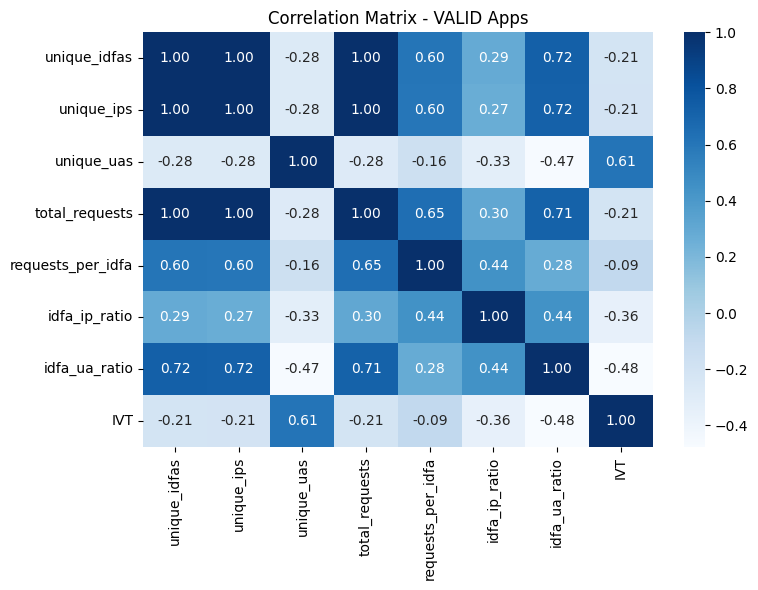

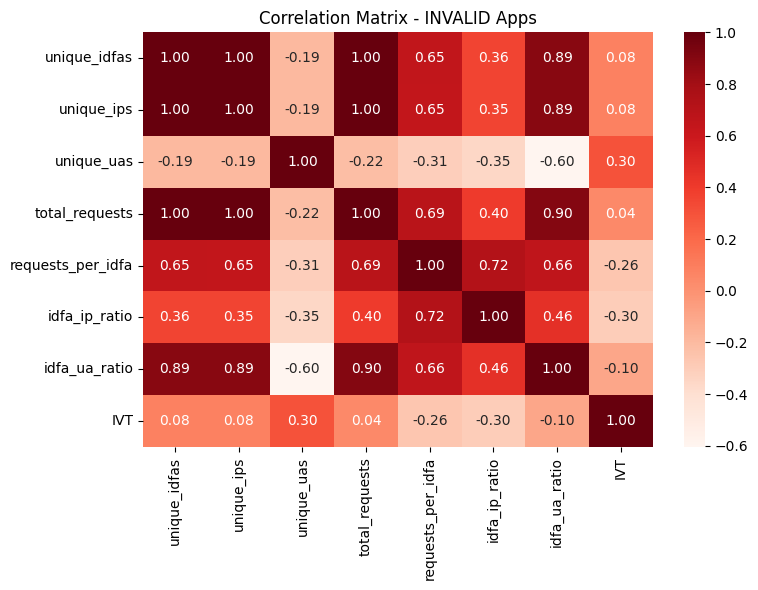

In [224]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['unique_idfas', 'unique_ips', 'unique_uas', 'total_requests', 
        'requests_per_idfa', 'idfa_ip_ratio', 'idfa_ua_ratio', 'IVT']

corr_valid = daily_valid_apps[cols].corr()
corr_invalid = daily_invalid_apps[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_valid, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Matrix - VALID Apps")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_invalid, annot=True, cmap='Reds', fmt=".2f")
plt.title("Correlation Matrix - INVALID Apps")
plt.tight_layout()
plt.show()



# Correlation Matrix - Hourly Data - VALID and INVALID Apps

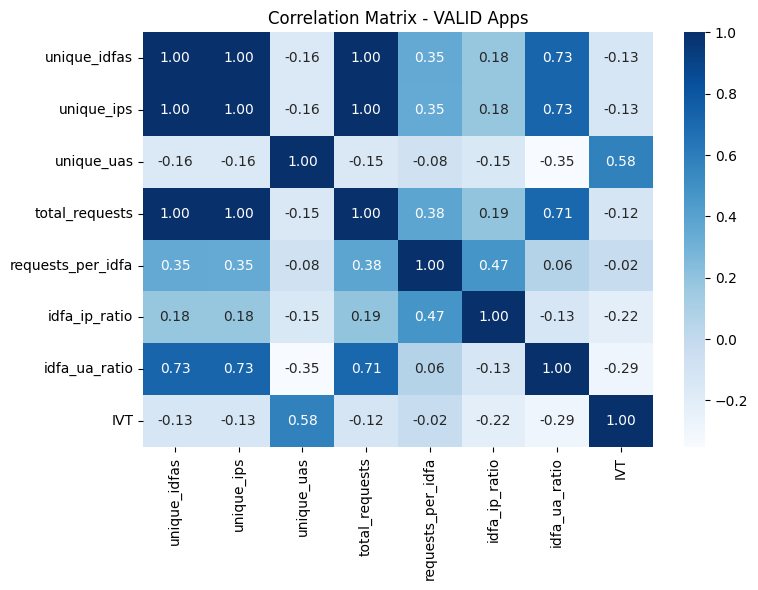

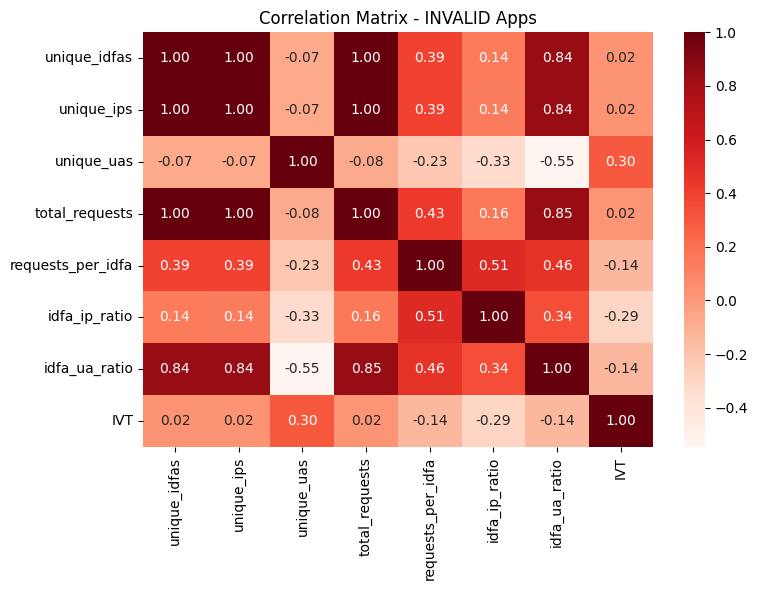

In [225]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['unique_idfas', 'unique_ips', 'unique_uas', 'total_requests', 
        'requests_per_idfa', 'idfa_ip_ratio', 'idfa_ua_ratio', 'IVT']

corr_valid = hourly_valid_apps[cols].corr()
corr_invalid = hourly_invalid_apps[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_valid, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Matrix - VALID Apps")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_invalid, annot=True, cmap='Reds', fmt=".2f")
plt.title("Correlation Matrix - INVALID Apps")
plt.tight_layout()
plt.show()

1. There is high correlations between unique_idfas, unique_ips and total_requests in both VALID and INVALID apps which does not show much significance.

2. idfa_ua_ratio correlation with requests is moderate high (0.72 daily; 0.73 hourly) in case of VALID Apps while its high (0.88-0.90) in INVALID Apps. These maybe fake devices in case of INVALID Apps.

3. unique_uas is much more negatively correlated with other metrics (-0.6 daily). Many UAs appear but are not tied to real device growth.

idfa_ua_ratio shows how many devices share the same user agent. Higher ratio indicates same User-Agent. 

1. The correlation between unique_uas and idfa_ua_ratio is more negative for invalid apps (-0.604). Hence, if uniqe_uas is low, that means idfa_ua_ratio is high which indicates number of user agents is very high or vice versa.

2. Hence, this indicates device spoofing.

## Column-wise visualisation in Power BI

# Conclusion

1. The apps marked with IVT was due to high number of unique_uas or User Agents with few unique_devices.

2. Hence, the apps were marked as IVT due to device spoofing.

3. IVT was not driven by volume - rather by behavioural patterns or metrics.

4. INVALID apps have a much lower ratio because they pretend to be unique by changing its UA.

# Data converted into csv files for Visualisation

In [53]:
daily_combined.to_csv("daily_combined.csv", index=False)
hourly_combined.to_csv("hourly_combined.csv", index=False)
